# Social Media Analytics — Lab 2

## Visualization of Virtual Communities and Explanation of Results

### Email-Eu-core Network

This laboratory work investigates virtual communities in an email
communication network. The analysis focuses on detecting communities,
visualizing their structure, identifying structurally important actors,
and examining connections between different communities.

## 1. Dataset Selection and Explanation

### Dataset Source

The Email-Eu-core dataset was obtained from the Stanford Large Network
Dataset Collection (SNAP).

Original dataset:
https://snap.stanford.edu/data/email-Eu-core.html

The selected dataset is the Email-Eu-core network. It represents email
communication between members of a large European research institution.

Each node represents an individual member of the institution. A directed
edge represents an email relationship between two members, where the
direction indicates the sender and recipient of the communication.

The dataset contains 1,005 nodes and 25,571 email relationships. In
addition to the network relationships, a separate file provides department
labels for the nodes. These labels provide useful contextual information
for interpreting the communities detected in the network.

The dataset was selected because email communication represents a form of
interaction between actors and can therefore be analyzed as a social
network. The department information also provides an opportunity to
compare the detected network communities with the organizational structure
of the institution.

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## 2. Loading the Dataset

The network relationships and department information are stored in two
separate files. The first file contains the email relationships, while the
second file contains the department associated with each node.

In [4]:
# Load email relationships

edges = pd.read_csv(
    "/content/sample_data/email-Eu-core.txt",
    sep=" ",
    header=None,
    names=["Source", "Target"]
)

edges.head()

,Source,Target
0,0,1
1,2,3
2,2,4
3,5,6
4,5,7


In [5]:
# Load department labels

departments = pd.read_csv(
    "/content/sample_data/email-Eu-core-department-labels.txt",
    sep=" ",
    header=None,
    names=["Node", "Department"]
)

departments.head()

,Node,Department
0,0,1
1,1,1
2,2,21
3,3,21
4,4,21


### Initial Data Inspection

The first step is to determine the number of relationships and nodes in
the dataset and to verify that the department file contains information
for the network nodes.

In [6]:
print("Number of relationships:", len(edges))
print("Number of department labels:", len(departments))
print(
    "Number of unique nodes:",
    len(set(edges["Source"]) | set(edges["Target"]))
)

Number of relationships: 25571
Number of department labels: 1005
Number of unique nodes: 1005


### Interpretation

The dataset contains **1,005 unique nodes** and **25,571 email
relationships**. There are also **1,005 department labels**, providing
department information for the network nodes.

The number of unique nodes in the relationship data matches the number of
department labels, indicating that the available department information
covers all nodes identified in the network.

## 3. Network Construction

The network is represented as a directed graph. This preserves the
direction of the email interaction: an edge from one node to another
represents communication from the first actor to the second actor.

Keeping the network directed allows the analysis to retain information
about the direction of communication rather than treating communication
between two people as automatically reciprocal.

In [7]:
# Create the directed network

G = nx.from_pandas_edgelist(
    edges,
    source="Source",
    target="Target",
    create_using=nx.DiGraph()
)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is the network directed?", G.is_directed())

Number of nodes: 1005
Number of edges: 25571
Is the network directed? True


In [8]:
print(
    "Number of weakly connected components:",
    nx.number_weakly_connected_components(G)
)

print(
    "Number of strongly connected components:",
    nx.number_strongly_connected_components(G)
)

Number of weakly connected components: 20
Number of strongly connected components: 203


### Interpretation of Network Connectivity

The network contains 20 weakly connected components. This means that when
the direction of email communication is ignored, the network is divided
into 20 connected groups.

When the direction of communication is taken into account, the network
contains 203 strongly connected components. This shows that directed
communication is more fragmented than the connectivity observed when edge
direction is ignored.

These connectivity characteristics provide useful background for the
community analysis, because the network contains both connected groups
and directional communication structures.

## 4. Community Detection Method

Community detection is used to identify groups of nodes that have stronger
connections within the group than with nodes outside the group.

For this analysis, the **Louvain community detection method** is selected.
The analysis was performed in **Python using the NetworkX library**.
Louvain is included among the community detection algorithms presented in
the course lecture.

The original Email-Eu-core network is directed because email communication
has a sender and a recipient. For community detection, the direction of
the email relationship will be ignored and the network will be converted
to an undirected graph. This allows the analysis to focus on the structure
of connections between actors and the formation of groups rather than the
direction of individual email messages.

The detected communities will then be compared with the department
information provided with the dataset. This additional information will
help us interpret what the detected communities may represent.

### Preparing the Network

Because the Louvain community detection analysis will focus on the
connections between actors, the directed email network is converted into
an undirected network for this step.

If two actors have an email relationship in either direction, they are
considered connected in the community-detection network.

In [9]:
# Convert the directed email network to an undirected network
G_undirected = G.to_undirected()

print("Nodes:", G_undirected.number_of_nodes())
print("Edges:", G_undirected.number_of_edges())
print("Is the network directed?", G_undirected.is_directed())

Nodes: 1005
Edges: 16706
Is the network directed? False


The original directed network contains 25,571 edges, while the
undirected network used for community detection contains 16,706 edges.
The reduction occurs because reciprocal relationships between the same pair
of actors are represented as a single undirected connection.

### Louvain Community Detection

The Louvain method is now applied to the undirected network. The method
groups nodes according to the structure of their connections and seeks a
community division with relatively strong connections within communities
and weaker connections between communities.

The resulting communities will be examined by their size and later
compared with the department labels supplied with the dataset.

In [10]:
# Detect communities using the Louvain method

communities = nx.community.louvain_communities(
    G_undirected,
    seed=42
)

print("Number of communities detected:", len(communities))

Number of communities detected: 28


In [11]:
# Calculate the size of each detected community

community_sizes = [len(community) for community in communities]

community_sizes_sorted = sorted(
    community_sizes,
    reverse=True
)

print("Community sizes (largest to smallest):")
for i, size in enumerate(community_sizes_sorted, start=1):
    print(f"Rank {i}: {size} nodes")

Community sizes (largest to smallest):
Rank 1: 251 nodes
Rank 2: 145 nodes
Rank 3: 129 nodes
Rank 4: 129 nodes
Rank 5: 111 nodes
Rank 6: 93 nodes
Rank 7: 64 nodes
Rank 8: 54 nodes
Rank 9: 10 nodes
Rank 10: 1 nodes
Rank 11: 1 nodes
Rank 12: 1 nodes
Rank 13: 1 nodes
Rank 14: 1 nodes
Rank 15: 1 nodes
Rank 16: 1 nodes
Rank 17: 1 nodes
Rank 18: 1 nodes
Rank 19: 1 nodes
Rank 20: 1 nodes
Rank 21: 1 nodes
Rank 22: 1 nodes
Rank 23: 1 nodes
Rank 24: 1 nodes
Rank 25: 1 nodes
Rank 26: 1 nodes
Rank 27: 1 nodes
Rank 28: 1 nodes


## 5. Community Visualization

The detected communities are visualized using different colors to make the
community structure distinguishable.. The network layout is calculated using the
Fruchterman-Reingold force-directed layout, which places strongly connected
nodes closer together and helps reveal the overall structure of the network.

Node size is scaled according to degree so that highly connected actors are
more visible in the network.

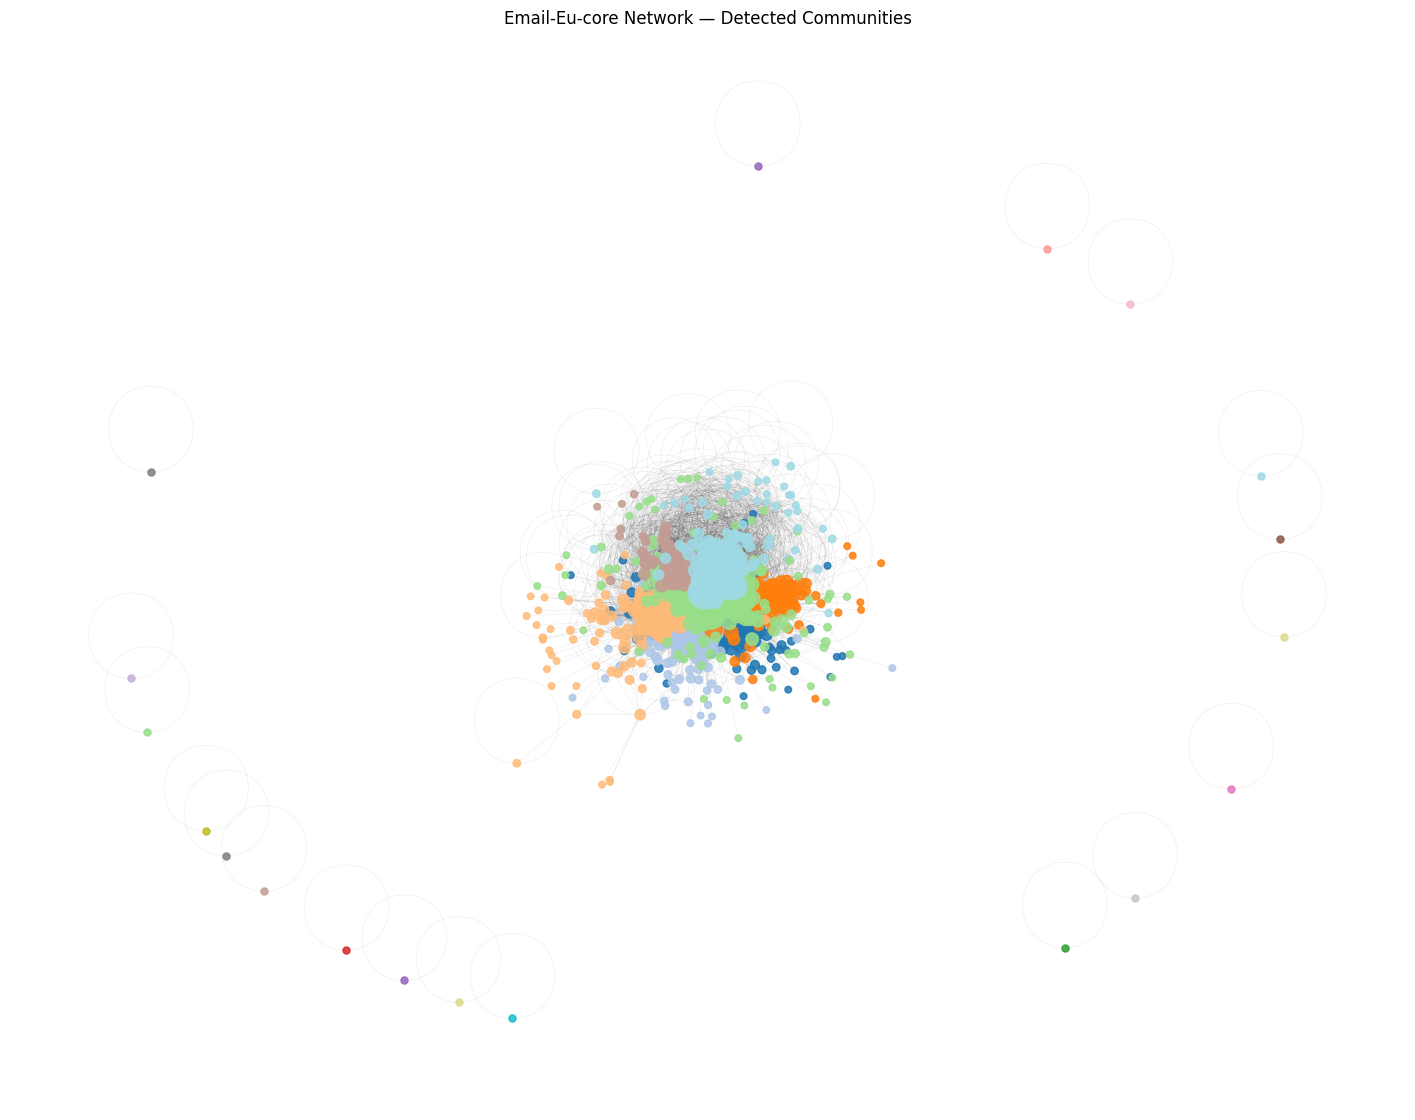

In [12]:
# Visualize the detected communities

plt.figure(figsize=(18, 14))

# Generate network layout
pos = nx.spring_layout(
    G_undirected,
    seed=42,
    k=0.15,
    iterations=100
)

# Node sizes based on degree
node_sizes = [
    20 + G_undirected.degree(node) * 3
    for node in G_undirected.nodes()
]

# Draw edges
nx.draw_networkx_edges(
    G_undirected,
    pos,
    alpha=0.08,
    width=0.4
)

# Draw nodes by community
for community_id, community in enumerate(communities):
    nx.draw_networkx_nodes(
        G_undirected,
        pos,
        nodelist=list(community),
        node_size=[
            node_sizes[list(G_undirected.nodes()).index(node)]
            for node in community
        ],
        node_color=[community_id] * len(community),
        cmap=plt.cm.tab20,
        vmin=0,
        vmax=max(len(communities) - 1, 1),
        alpha=0.85,
        label=f"Community {community_id + 1}"
    )

plt.title("Email-Eu-core Network — Detected Communities")
plt.axis("off")
plt.show()

## 6. Community Sizes

### Main Community Sizes

The Louvain method identified **28 communities** in the network. The
communities vary considerably in size.

The largest detected community contains **251 nodes**, followed by
communities containing 145, 129, 129, 111, and 93 nodes. The remaining
larger communities contain between 10 and 64 nodes.

The algorithm also identified 19 communities consisting of a single node.
These single-node communities will be considered separately when
interpreting the overall community structure. Therefore, the number
of detected communities alone is not sufficient to describe the structure
of the network; the distribution and relationships of the communities must
also be considered.

In [13]:
# Create a mapping from node to community

node_to_community = {}

for community_id, community in enumerate(communities):
    for node in community:
        node_to_community[node] = community_id

print("Nodes assigned to communities:", len(node_to_community))

Nodes assigned to communities: 1005


## 7. Community-Level Network

The complete network contains 1,005 nodes, making a direct visualization
difficult to interpret. Therefore, a second visualization is created at the
community level.

In this representation, each node represents one detected community.
The size of a community node corresponds to the number of members in that
community, while an edge represents connections between two different communities in the undirected network.
The thickness of an edge represents the number of cross-community
connections in the undirected network.
This provides a clearer view of how the detected
communities are connected to one another.

In [14]:
# Create a community-level graph

community_graph = nx.Graph()

# Add communities as nodes
for community_id, community in enumerate(communities):
    community_graph.add_node(
        community_id,
        size=len(community)
    )

# Count relationships between different communities
for u, v in G_undirected.edges():

    community_u = node_to_community[u]
    community_v = node_to_community[v]

    if community_u != community_v:

        if community_graph.has_edge(community_u, community_v):
            community_graph[community_u][community_v]["weight"] += 1
        else:
            community_graph.add_edge(
                community_u,
                community_v,
                weight=1
            )

print("Number of communities:", community_graph.number_of_nodes())
print(
    "Number of community-to-community connections:",
    community_graph.number_of_edges()
)

Number of communities: 28
Number of community-to-community connections: 36


## 8. Community-Level Visualization

The community-level network provides a simplified view of the detected
community structure. Each node represents one detected community, and its
size is proportional to the number of members in that community.

Edges represent email relationships between different communities. A
Edges represent connections between different communities in the
undirected network. A thicker edge indicates a larger number of connections
between the corresponding communities.

This visualization makes it easier to identify large communities,
communities with many external connections, and communities that have
relatively few connections with the rest of the network.

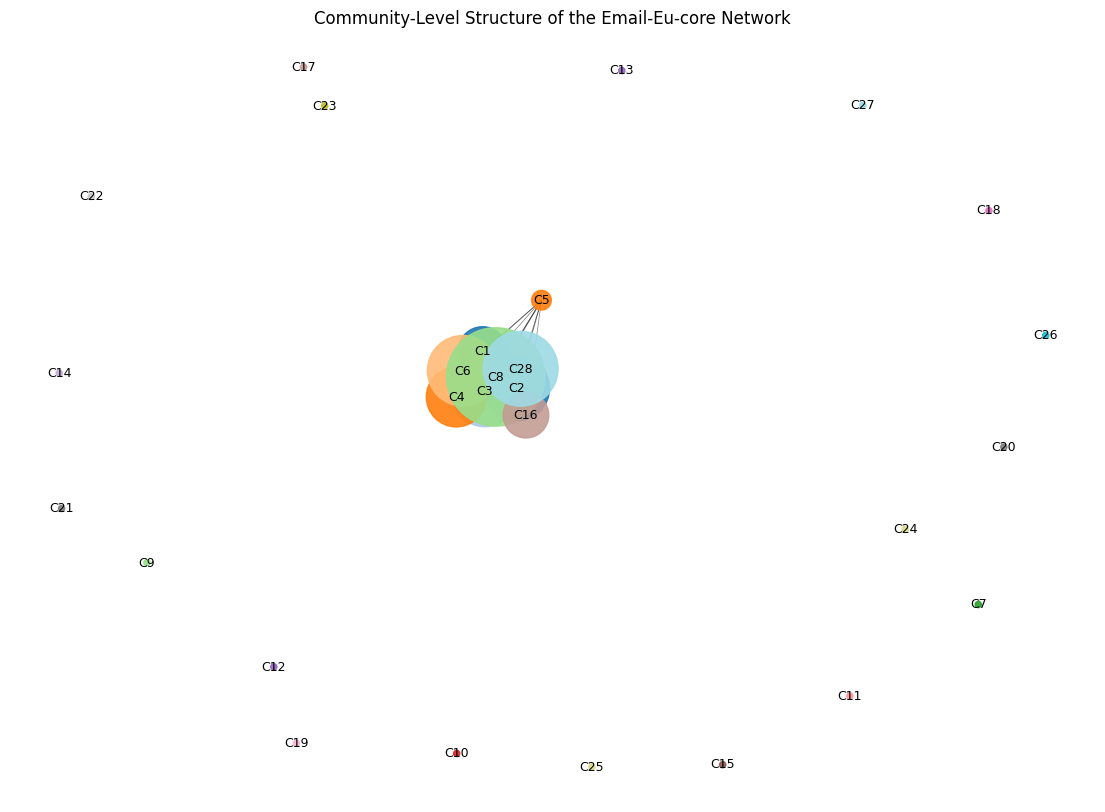

In [15]:
# Visualize the community-level network

plt.figure(figsize=(14, 10))

community_pos = nx.spring_layout(
    community_graph,
    seed=42,
    k=1.5
)

# Community node sizes
community_node_sizes = [
    community_graph.nodes[node]["size"] * 20
    for node in community_graph.nodes()
]

# Edge widths based on number of cross-community relationships
edge_widths = [
    0.5 + community_graph[u][v]["weight"] / 100
    for u, v in community_graph.edges()
]

nx.draw_networkx_edges(
    community_graph,
    community_pos,
    width=edge_widths,
    alpha=0.5
)

nx.draw_networkx_nodes(
    community_graph,
    community_pos,
    node_size=community_node_sizes,
    node_color=list(community_graph.nodes()),
    cmap=plt.cm.tab20,
    alpha=0.9
)

nx.draw_networkx_labels(
    community_graph,
    community_pos,
    labels={
        node: f"C{node + 1}"
        for node in community_graph.nodes()
    },
    font_size=9
)

plt.title("Community-Level Structure of the Email-Eu-core Network")
plt.axis("off")
plt.show()

### Main Community Structure

Because several detected communities consist of only one node, a second
visualization is provided to focus on the nine communities containing at
least ten nodes. This makes the structure of the main communities easier
to examine without removing the smaller communities from the original
analysis.

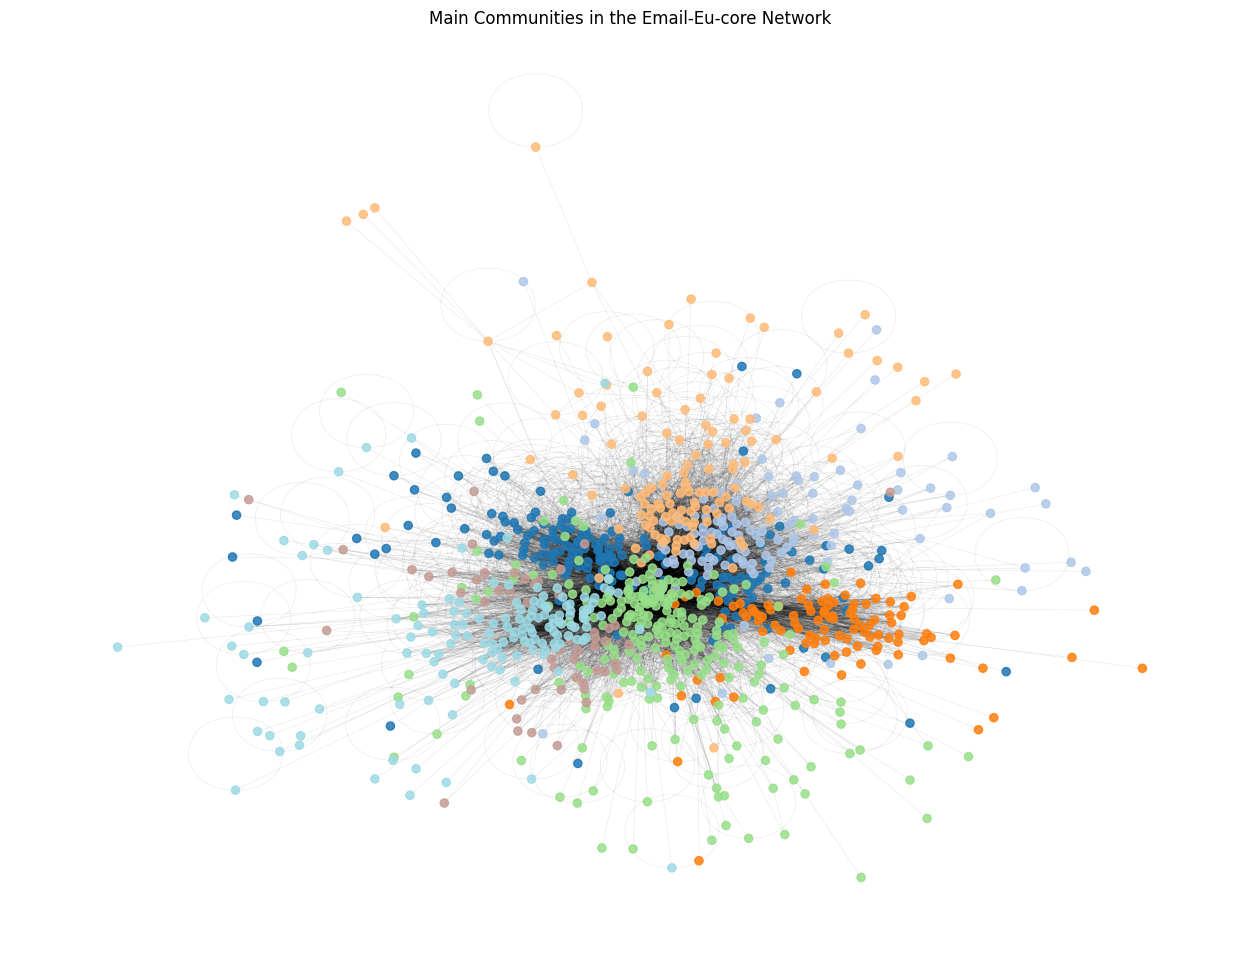

In [16]:
# Visualize the main communities only

main_communities = [
    community_id
    for community_id, community in enumerate(communities)
    if len(community) >= 10
]

main_nodes = set()

for community_id in main_communities:
    main_nodes.update(communities[community_id])

G_main = G_undirected.subgraph(main_nodes).copy()

plt.figure(figsize=(16, 12))

pos_main = nx.spring_layout(
    G_main,
    seed=42,
    k=0.25,
    iterations=100
)

for community_id in main_communities:
    nodes = list(communities[community_id])

    nx.draw_networkx_nodes(
        G_main,
        pos_main,
        nodelist=nodes,
        node_size=35,
        node_color=[community_id] * len(nodes),
        cmap=plt.cm.tab20,
        vmin=0,
        vmax=max(main_communities),
        alpha=0.85
    )

nx.draw_networkx_edges(
    G_main,
    pos_main,
    alpha=0.08,
    width=0.5
)

plt.title("Main Communities in the Email-Eu-core Network")
plt.axis("off")
plt.show()

### Interpretation of the Main Community Visualization

The visualization shows nine main communities containing at least ten
nodes. The communities form a large interconnected central structure
rather than appearing as completely isolated groups.

The different colors make the main communities distinguishable, while the
network layout shows that several communities have substantial
connections with one another. Some groups are more concentrated and
compact, while others extend outward through connections with actors in
other communities.

This visualization provides a clearer representation of the main
community structure than the full network because the 19 single-node
communities have been excluded from this particular view. They remain
included in the overall community analysis.

In [17]:
# Strongest connections between communities

community_edges = pd.DataFrame(
    [
        {
            "Community 1": u + 1,
            "Community 2": v + 1,
            "Network Connections": data["weight"]
        }
        for u, v, data in community_graph.edges(data=True)
    ]
)

community_edges = community_edges.sort_values(
    "Network Connections",
    ascending=False
)

community_edges.head(10)

,Community 1,Community 2,Network Connections
33,8,28,815
9,2,8,801
17,3,8,725
5,1,8,556
31,6,8,490
18,3,6,405
12,2,3,394
22,4,8,384
34,8,16,263
8,2,28,209


## 9. Important Actors and Bridges

Important actors are identified using degree and betweenness centrality.
Degree indicates how many direct connections an actor has, while
betweenness centrality indicates how often an actor lies on shortest paths
between other actors.

Actors with high degree can function as highly connected hubs. Actors with
high betweenness may have an important position between different parts of
the network and can potentially connect different communities.

In [18]:
# Calculate degree and betweenness centrality

degree = dict(G_undirected.degree())
betweenness = nx.betweenness_centrality(G_undirected)

important_nodes = pd.DataFrame({
    "Node": list(G_undirected.nodes()),
    "Degree": [degree[n] for n in G_undirected.nodes()],
    "Betweenness": [betweenness[n] for n in G_undirected.nodes()],
    "Community": [
        node_to_community[n] + 1
        for n in G_undirected.nodes()
    ]
})

important_nodes = important_nodes.sort_values(
    "Degree",
    ascending=False
)

important_nodes.head(10)

,Node,Degree,Betweenness,Community
160,160,347,0.087415,6
121,121,234,0.027842,8
82,82,233,0.027881,8
107,107,221,0.024340,8
86,86,218,0.037789,3
62,62,216,0.022510,8
434,434,185,0.015413,8
13,13,180,0.023565,2
166,166,177,0.017639,8
183,183,173,0.012309,3


In [19]:
# Top actors by betweenness

important_nodes_by_betweenness = important_nodes.sort_values(
    "Betweenness",
    ascending=False
)

important_nodes_by_betweenness.head(10)

,Node,Degree,Betweenness,Community
160,160,347,0.087415,6
86,86,218,0.037789,3
5,5,171,0.030995,28
82,82,233,0.027881,8
121,121,234,0.027842,8
107,107,221,0.024340,8
13,13,180,0.023565,2
377,377,139,0.023175,6
62,62,216,0.022510,8
64,64,170,0.021924,3


In [20]:
# Identify actors whose connections span multiple communities

bridge_nodes = []

for node in G_undirected.nodes():

    neighboring_communities = {
        node_to_community[neighbor]
        for neighbor in G_undirected.neighbors(node)
    }

    if len(neighboring_communities) > 1:
        bridge_nodes.append({
            "Node": node,
            "Community": node_to_community[node] + 1,
            "Degree": degree[node],
            "Betweenness": betweenness[node],
            "Connected_Communities": len(neighboring_communities)
        })

bridge_df = pd.DataFrame(bridge_nodes)

bridge_df = bridge_df.sort_values(
    ["Connected_Communities", "Betweenness"],
    ascending=False
)

bridge_df.head(10)

,Node,Community,Degree,Betweenness,Connected_Communities
155,160,6,347,0.087415,9
84,86,3,218,0.037789,9
5,5,28,171,0.030995,9
12,13,2,180,0.023565,9
60,62,8,216,0.022510,9
62,64,3,170,0.021924,9
82,84,8,132,0.018569,9
772,971,4,97,0.016698,9
398,411,28,106,0.014345,9
125,129,3,164,0.013625,9


### Interpretation of Important Actors

Several actors occupy structurally important positions in the network.

Node 160 has the highest degree, with 347 direct connections, and also has
the highest betweenness centrality value (0.087415). It belongs to
Community 6 and has connections with 9 different detected communities.
This makes Node 160 both a highly connected actor and an important
cross-community actor.

Other highly connected actors include Nodes 121, 82, 107, and 86.
Several of these actors are connected to multiple communities, indicating
that they participate in interactions extending beyond their own detected
community.

These results suggest that some actors function as hubs within the
network, while others may also contribute to communication between
different communities.

## 10. Community Structure

The detected communities are not completely separated. The
community-level visualization shows a large central group of communities
with multiple connections between them, while several smaller communities
have few or no visible connections to the main structure.

There are 36 connections between the 28 detected communities. Some
community pairs have substantially more interactions than others. For
example, For example, Community 8 has 815 network connections with Community 28,
801 with Community 2, and 725 with Community 3.

The network therefore contains both internally organized communities and
substantial interaction between some communities. The structure is better
described as interconnected communities rather than completely isolated
groups.
Community size and connectivity differences are visible in the analysis,
but community density was not calculated separately. Therefore, no direct
claim is made about which community is the densest.

## 11. Community Composition and Department Information

The dataset provides department labels for all 1,005 nodes. These labels
are used to examine whether the communities detected from the email
network correspond to particular organizational departments.

The comparison is based on the distribution of department memberships
within each detected community. This helps provide additional context when
interpreting what the detected communities represent.

In [21]:
# Compare detected communities with department labels

departments["Community"] = departments["Node"].map(node_to_community)

department_summary = []

for community_id in sorted(departments["Community"].unique()):
    group = departments[
        departments["Community"] == community_id
    ]

    counts = group["Department"].value_counts()

    department_summary.append({
        "Community": community_id + 1,
        "Community Size": len(group),
        "Dominant Department": counts.index[0],
        "Dominant Department Members": counts.iloc[0],
        "Dominant Department %": round(
            counts.iloc[0] / len(group) * 100,
            2
        )
    })

department_summary = pd.DataFrame(department_summary)

department_summary.sort_values(
    "Community Size",
    ascending=False
)

,Community,Community Size,Dominant Department,Dominant Department Members,Dominant Department %
7,8,251,15,47,18.73
27,28,145,21,53,36.55
5,6,129,7,48,37.21
2,3,129,4,93,72.09
1,2,111,10,38,34.23
3,4,93,14,88,94.62
0,1,64,1,43,67.19
15,16,54,17,32,59.26
4,5,10,2,8,80.00
9,10,1,21,1,100.00


### Interpretation

The department comparison shows that the detected communities differ in
how strongly they are associated with particular departments.

Several communities have a clear dominant department. For example,
Community 4 has 94.62% of its members from Department 14, while Community 3
has 72.09% from Department 4 and Community 1 has 67.19% from Department 1.

However, the largest community, Community 8, has a much lower department
concentration of 18.73%. This indicates that it contains members from
multiple departments.

Therefore, the detected communities cannot simply be treated as
department groups. They appear to capture both organizational structure
and patterns of communication between members.

## 12. Type of Virtual Community

The Email-Eu-core network is most closely related to an **in-group
community**.

The network represents communication among members of the same research
institution, and the detected communities consist of groups of actors who
interact more strongly with some members than with others. The network
also contains connections between these groups, showing that the
communities are not completely isolated.

The department analysis provides additional evidence for this
interpretation. Some communities are strongly concentrated around
particular departments, while others contain members from several
departments. This suggests that both organizational affiliation and
communication patterns contribute to the observed community structure.

The network does not perfectly represent an in-group community because
there are substantial connections between several detected communities.
Therefore, the classification should be understood as the closest
community type rather than an exact classification.

## 13. Meaning of the Detected Communities

The detected communities represent groups of institution members who have
relatively strong patterns of email interaction with one another.

The department labels provide additional context for interpreting these
communities. The results show that some communities are strongly
concentrated around particular departments, while others contain members
from several departments.

For example, Community 4 contains 93 nodes, of which 88 (94.62%) belong to
Department 14. Community 1 contains 64 nodes, with 43 (67.19%) belonging
to Department 1. Community 3 contains 129 nodes, with 93 (72.09%) belonging
to Department 4. Community 5 contains 10 nodes, with 8 (80%) belonging to
Department 2.

In contrast, the largest community, Community 8, contains 251 nodes and
its largest department group contains only 47 nodes (18.73%). This suggests
that this community is more mixed and does not correspond closely to a
single department.

These results show that some detected network communities may reflect
organizational departments or groups of closely interacting colleagues,
while other communities may reflect communication patterns that cross
department boundaries.

The network therefore provides evidence about patterns of interaction,
but it does not by itself establish why these communities exist. The
department labels provide organizational context, while the Louvain
communities are determined from the structure of the email network.

## 14. Connections Between Communities

The community-level analysis identified **36 connections between the 28
detected communities**.

The strength of these connections varies considerably. The strongest
observed connection is between **Community 8 and Community 28**, with
**815 network connections**. Other strong connections include **Community
2 and Community 8**, with **801 netwoek connections**, and **Community 3 and
Community 8**, with **725 network connections**.

These results show that some communities are strongly interconnected,
rather than being completely isolated from one another. Community 8 is
particularly well connected to several other communities and therefore
appears to occupy an important position in the community-level network.

The actor-level analysis provides additional evidence of connections
between communities. Several actors were found to have connections
spanning **9 different communities**. Node 160 is particularly notable:
it has the highest degree (347), the highest betweenness centrality
(0.087415), and connections to 9 communities.

These cross-community connections indicate that communication and
potential information flow occur between the detected groups. However,
the network alone cannot establish what information was exchanged or why
the actors communicated across communities.

## 15. Limitations

The analysis represents email relationships as network connections, but
the existence of an email relationship does not necessarily indicate the
strength or nature of a social relationship.

The Louvain algorithm also produces communities based on network
structure, so the detected communities should not automatically be
interpreted as formal organizational departments.

In addition, the visualization simplifies a relatively large network of
1,005 nodes and 25,571 original directed relationships. Some details of
individual interactions are therefore difficult to observe in the full
network visualization.

Finally, the analysis describes the observed network structure but does
not establish why particular communities or communication patterns exist.
Additional information about the participants, their roles, and the
content of their communication would be required to make stronger
conclusions.

## 16. Conclusion

The Email-Eu-core dataset was analyzed as a social network representing email communication between members of a European research institution. The network contains 1,005 nodes and 25,571 directed relationships.

Louvain community detection identified 28 communities. The communities vary considerably in size, with the largest containing 251 nodes. The community-level visualization showed that the detected groups are not completely isolated and that several communities have substantial connections with one another.

The actor analysis identified highly connected nodes and actors that connect multiple communities. Node 160 had the highest degree (347) and highest betweenness centrality (0.087415) among the analyzed nodes and was connected to nine detected communities.

The network can be interpreted as an in-group professional communication network, although the detected communities do not necessarily correspond directly to formal departments. The department information supplied with the dataset provides additional context for interpreting the detected groups.

Overall, the analysis demonstrates how community detection and network visualization can be used to identify groups, important actors, and connections between communities in a social communication network.